In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f'x_train shape: {x_train.shape}, y_train shape: {y_train.shape}')
print(f'x_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
x_train shape: (50000, 32, 32, 3), y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3), y_test shape: (10000, 1)


*CNN model*

In [ ]:
def create_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10)
    ])
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model

*Without Data Augmentation*

In [ ]:
model_no_aug = create_cnn()
history_no_aug = model_no_aug.fit(x_train, y_train, epochs=30, validation_data=(x_test, y_test), batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 78ms/step - accuracy: 0.3196 - loss: 1.8464 - val_accuracy: 0.5034 - val_loss: 1.3666
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 76ms/step - accuracy: 0.5439 - loss: 1.2901 - val_accuracy: 0.5706 - val_loss: 1.2066
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 77ms/step - accuracy: 0.6041 - loss: 1.1213 - val_accuracy: 0.6247 - val_loss: 1.0664
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.6458 - loss: 1.0056 - val_accuracy: 0.6337 - val_loss: 1.0497
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.6789 - loss: 0.9230 - val_accuracy: 0.6620 - val_loss: 0.9575
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.7022 - loss: 0.8576 - val_accuracy: 0.6830 - val_loss: 0.8939
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.7200 - loss: 0.8057 - val_accuracy: 0.6917 - val_loss: 0.8946
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 78ms/step - accuracy: 0.7387 - loss: 0.7461 - 

*With Data Augmentation*

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
model_aug = create_cnn()
history_aug = model_aug.fit(datagen.flow(x_train, y_train, batch_size=64),
                            epochs=30, validation_data=(x_test, y_test))

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 117ms/step - accuracy: 0.3118 - loss: 1.8498 - val_accuracy: 0.5195 - val_loss: 1.3346
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 111ms/step - accuracy: 0.4974 - loss: 1.3972 - val_accuracy: 0.5681 - val_loss: 1.2107
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 109ms/step - accuracy: 0.5573 - loss: 1.2447 - val_accuracy: 0.5666 - val_loss: 1.2244
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 110ms/step - accuracy: 0.5872 - loss: 1.1664 - val_accuracy: 0.6410 - val_loss: 1.0219
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 110ms/step - accuracy: 0.6065 - loss: 1.1071 - val_accuracy: 0.6652 - val_loss: 0.9638
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 111ms/step - accuracy: 0.6296 - loss: 1.0540 - val_accuracy: 0.6509 - val_loss: 1.0131
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 110ms/step - accuracy: 0.6403 - loss: 1.0176 - val_accuracy: 0.6753 - val_loss: 0.9412
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 116ms/step - accuracy: 0.6551 - loss: 0.9834 - val

*Accuracy Comparison*

In [ ]:
test_loss_no_aug, test_acc_no_aug = model_no_aug.evaluate(x_test, y_test, verbose=2)
test_loss_aug, test_acc_aug = model_aug.evaluate(x_test, y_test, verbose=2)

print(f"Without augmentation: Test accuracy = {test_acc_no_aug}")
print(f"With augmentation: Test accuracy = {test_acc_aug}")

313/313 - 3s - 11ms/step - accuracy: 0.6908 - loss: 1.3616
313/313 - 4s - 14ms/step - accuracy: 0.7624 - loss: 0.7041
Without augmentation: Test accuracy = 0.6908000111579895
With augmentation: Test accuracy = 0.7623999714851379


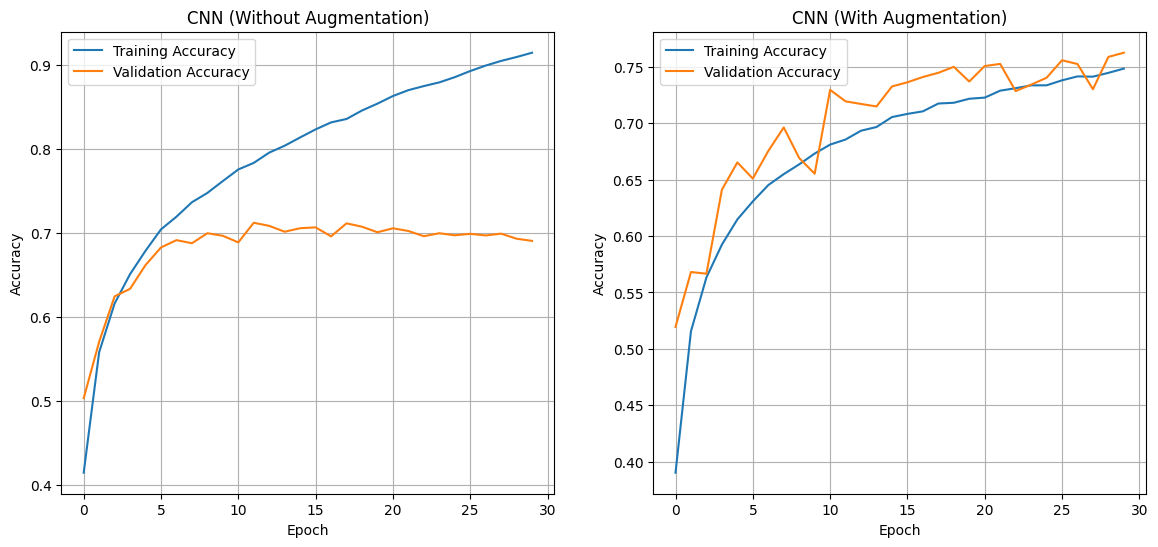

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# CNN without augmentation
ax1.plot(history_no_aug.history['accuracy'], label='Training Accuracy')
ax1.plot(history_no_aug.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('CNN (Without Augmentation)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# CNN with augmentation
ax2.plot(history_aug.history['accuracy'], label='Training Accuracy')
ax2.plot(history_aug.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('CNN (With Augmentation)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.show()


*Visualization of feature maps and filters from one convolutional layer.*

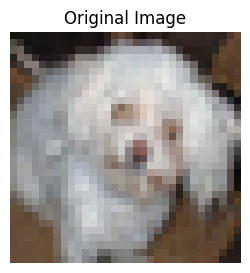

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


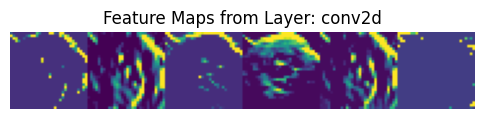

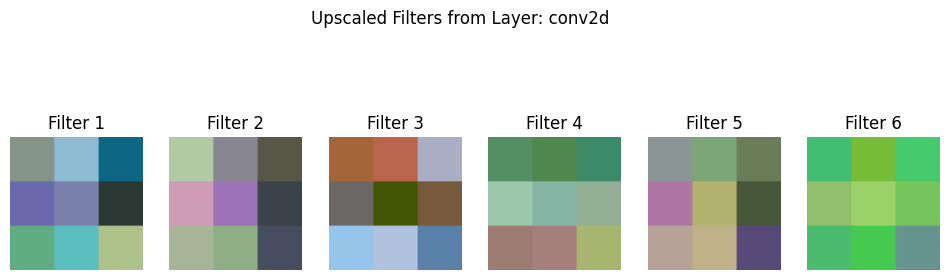

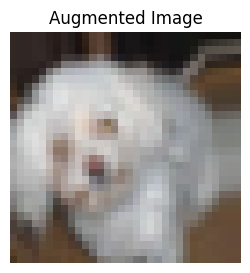

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


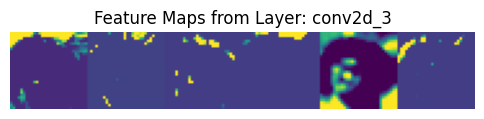

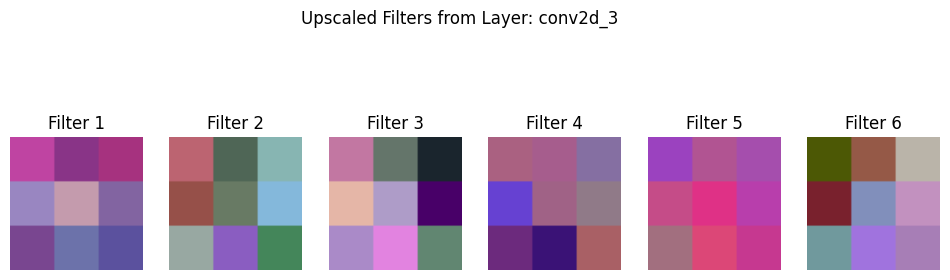

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def visualize_cnn(model, image, max_features=6, upscale_factor=20, augment=False):
    if augment:
        datagen = ImageDataGenerator(
            rotation_range=15,
            horizontal_flip=True,
            zoom_range=0.1,
            width_shift_range=0.1,
            height_shift_range=0.1
        )
        image_batch = image.reshape(1, *image.shape)
        aug_iter = datagen.flow(image_batch, batch_size=1)
        image = next(aug_iter)[0]

    plt.figure(figsize=(3, 3))
    title_text = "Augmented Image" if augment else "Original Image"
    plt.imshow(image)
    plt.title(title_text)
    plt.axis("off")
    plt.show()

    # Feature Maps
    input_layer = tf.keras.Input(shape=image.shape)
    x = input_layer
    conv_outputs = []

    for layer in model.layers:
        x = layer(x)
        if 'conv' in layer.name:
            conv_outputs.append(x)

    activation_model = models.Model(inputs=input_layer, outputs=conv_outputs)

    image_batch = image.reshape(1, *image.shape)
    feature_maps = activation_model.predict(image_batch)

    conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name]
    first_layer_name = conv_layer_names[0]
    first_feature_map = feature_maps[0]

    n_features = first_feature_map.shape[-1]
    size = first_feature_map.shape[1]

    display_grid = np.zeros((size, size * min(n_features, max_features)))
    for i in range(min(n_features, max_features)):
        feature_image = first_feature_map[0, :, :, i]
        feature_image -= feature_image.mean()
        feature_image /= (feature_image.std() + 1e-5)
        feature_image *= 64
        feature_image += 128
        feature_image = np.clip(feature_image, 0, 255).astype('uint8')
        display_grid[:, i * size : (i + 1) * size] = feature_image

    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0]))
    plt.title(f"Feature Maps from Layer: {first_layer_name}")
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.axis('off')
    plt.show()

    # Upscaled Filters
    first_conv_layer = model.get_layer(first_layer_name)
    filters, biases = first_conv_layer.get_weights()

    f_min, f_max = filters.min(), filters.max()
    filters = (filters - f_min) / (f_max - f_min)

    plt.figure(figsize=(12, 4))
    for i in range(min(max_features, filters.shape[-1])):
        f = filters[:, :, :, i]
        f_upscaled = np.kron(f, np.ones((upscale_factor, upscale_factor, 1)))
        plt.subplot(1, max_features, i + 1)
        plt.imshow(f_upscaled)
        plt.title(f"Filter {i+1}")
        plt.axis('off')
    plt.suptitle(f"Upscaled Filters from Layer: {first_layer_name}")
    plt.show()

# Visualize original image + feature maps + filters
visualize_cnn(model_no_aug, x_test[1000], augment=False)

# Visualize augmented image + feature maps + filters
visualize_cnn(model_aug, x_test[1000], augment=True)
